In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import seaborn as sns
from sklearn.cluster import KMeans

def custom_grouping(index):
    return index // 1000

names_bw=['submission_time', 'bw', 'op1', 'write_size', 'op2' ]
columns = ['submission_time', 'bw', 'write_size']


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Total_time: 90016.049


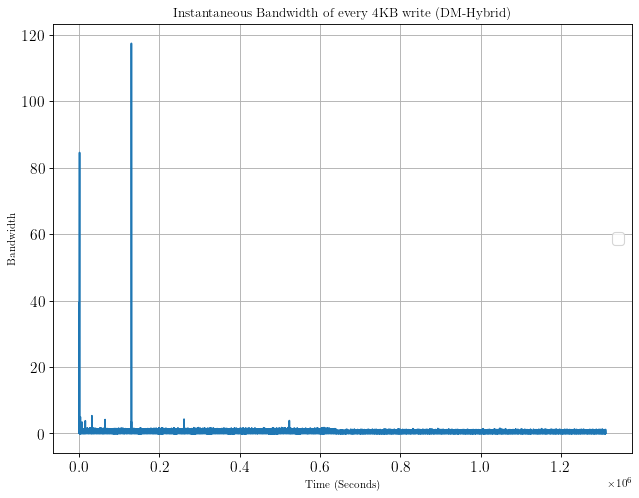

In [12]:
# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv('/home/surbhi/measurements/worst_case/STL/4K/90-10-LBA/90Util/bw_log_avg_bw.1.log', names=names_bw, usecols=columns)
#df = pd.read_csv('/home/surbhi/measurements/worst_case/HM-Hybrid/4KB/90-10-LBA/90Util/15Zones.WakeOne/bw_log_avg_bw.1.log', names=names_bw, usecols=columns)
#df = pd.read_csv('/home/surbhi/measurements/worst_case/lsdm/4K/90-10-LBA/90Util/lat_log_avg_lat.1.log', names=names_bw, usecols=columns)
df['submission_time'] = df['submission_time'] - df.iloc[0].submission_time
total_time = df.iloc[-1].submission_time
total_time = total_time / 1000
print("Total_time: " + str(total_time))
# Step 2: Convert submission time and completion time columns to datetime objects with unit as milliseconds
df['submission_time'] = pd.to_datetime(df['submission_time'], unit='ms')
#print(df)
# Plot vertical lines at x where y is higher than the threshold
# Plot the data size over time for each resolution
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df.index, df['bw']/1024)
plt.xlabel('Time (Seconds)')
plt.ylabel('Bandwidth')
plt.title("Instantaneous Bandwidth of every 4KB write (DM-Hybrid)")
plt.legend(loc='center right', fontsize=14)
plt.grid(True)  # Optionally, add grid lines
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Total_time: 136402.502


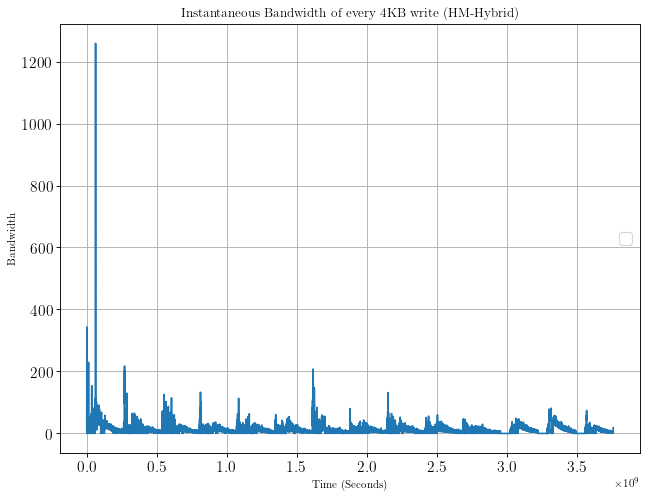

In [39]:
# Step 1: Read the CSV file into a Pandas DataFrame
#df = pd.read_csv('/home/surbhi/measurements/worst_case/STL/4K/90-10-LBA/90Util/bw_log_avg_bw.1.log', names=names_bw, usecols=columns)
df = pd.read_csv('/home/surbhi/measurements/worst_case/HM-Hybrid/4KB/90-10-LBA/90Util/15Zones.WakeOne/bw_log_avg_bw.1.log', names=names_bw, usecols=columns)
#df = pd.read_csv('/home/surbhi/measurements/worst_case/lsdm/4K/90-10-LBA/90Util/lat_log_avg_lat.1.log', names=names_bw, usecols=columns)
df['submission_time'] = df['submission_time'] - df.iloc[0].submission_time
total_time = df.iloc[-1].submission_time
total_time = total_time / 1000
print("Total_time: " + str(total_time))
df_new = df.groupby('submission_time').sum().reset_index()
#df_grouped = df_new.groupby(custom_grouping).sum()
df_grouped = df_new
df_grouped['cumulative_gbs'] = df_grouped['write_size'].cumsum()/ (1024 ** 3)

plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
#plt.plot(df.index, df['bw']/(1024))
#plt.plot(df_grouped.index, df_grouped['bw']/1024)
plt.plot(df_grouped['cumulative_gbs'], df_grouped['bw']/1024)
plt.xlabel('Time (Seconds)')
plt.ylabel('Bandwidth')
plt.title("Instantaneous Bandwidth of every 4KB write (HM-Hybrid)")
plt.legend(loc='center right', fontsize=14)
plt.grid(True)  # Optionally, add grid lines
plt.show() 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Total_time: 1936.896


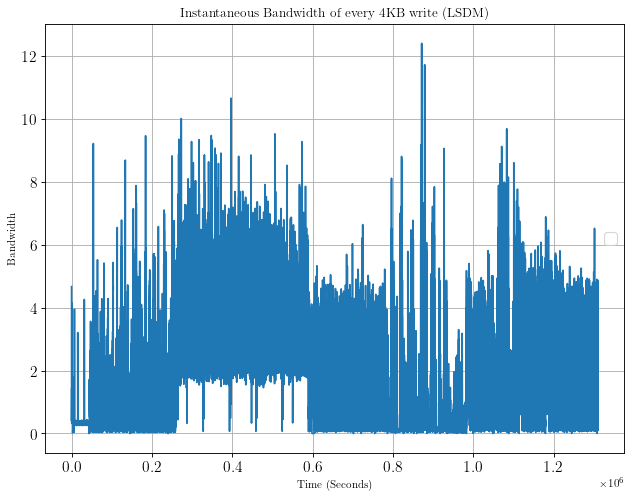

In [40]:
# Step 1: Read the CSV file into a Pandas DataFrame
#df = pd.read_csv('/home/surbhi/measurements/worst_case/STL/4K/90-10-LBA/90Util/bw_log_avg_bw.1.log', names=names_bw, usecols=columns)
#df = pd.read_csv('/home/surbhi/measurements/worst_case/HM-Hybrid/4KB/90-10-LBA/90Util/15Zones.WakeOne/bw_log_avg_bw.1.log', names=names_bw, usecols=columns)
df = pd.read_csv('/home/surbhi/measurements/worst_case/lsdm/4K/90-10-LBA/90Util/bw_log_avg_bw.1.log', names=names_bw, usecols=columns)

df['submission_time'] = df['submission_time'] - df.iloc[0].submission_time
total_time = df.iloc[-1].submission_time
total_time = total_time / 1000
print("Total_time: " + str(total_time))
# Step 2: Convert submission time and completion time columns to datetime objects with unit as milliseconds
df['submission_time'] = pd.to_datetime(df['submission_time'], unit='ms')
#print(df)
# Plot vertical lines at x where y is higher than the threshold
# Plot the data size over time for each resolution
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df.index, df['bw']/1024)
plt.xlabel('Time (Seconds)')
plt.ylabel('Bandwidth')
plt.title("Instantaneous Bandwidth of every 4KB write (LSDM)")
plt.legend(loc='center right', fontsize=14)
plt.grid(True)  # Optionally, add grid lines
plt.show()